In [4]:
import pandas as pd
import numpy as np

In [5]:
from prophet.diagnostics import cross_validation, performance_metrics

In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick 
import seaborn as sns

In [7]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

In [8]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error

In [9]:
pip install prophet


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
from prophet import Prophet
from prophet.plot import add_changepoints_to_plot

In [11]:
df = pd.read_csv(r"C:\Git_test\Digital Native Challenge\Vgsales_Cleaned_Data_test.csv", usecols=['Year', 'Global Sales'])

In [12]:
print(df.dtypes)


Year             object
Global Sales    float64
dtype: object


In [13]:
df['Year'] = df['Year'].astype(str).str[:4]

df['Year'] = pd.to_datetime(df['Year'], format='%Y')

In [14]:
print(df['Year'].dtype)

datetime64[ns]


In [15]:
df.dropna(subset='Year', inplace=True)

In [16]:
df = df.rename(columns={'Year':'ds', 'Global Sales':'y'})

In [17]:
print(df['ds'].dtype)

datetime64[ns]


In [199]:
df_agg = df.groupby('ds')['y'].sum().reset_index()

df_agg_up_to_2016 = df_agg[df_agg['ds'].dt.year <= 2016]

split_idx = int(len(df_agg_up_to_2016) * 0.8)
train_df = df_agg_up_to_2016.iloc[:split_idx]
test_df = df_agg_up_to_2016.iloc[split_idx:]

In [232]:
model = Prophet(changepoint_prior_scale=0.01,
    seasonality_prior_scale=0.1,
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    growth='linear')
model.fit(train_df)

15:59:26 - cmdstanpy - INFO - Chain [1] start processing
15:59:26 - cmdstanpy - INFO - Chain [1] done processing


In [233]:
future = model.make_future_dataframe(periods=len(test_df))
forecast = model.predict(future)

In [234]:
test_forecast = forecast.iloc[-len(test_df):]

In [235]:
train_forecast = model.predict(train_df[['ds']])
y_pred_train = train_forecast['yhat'].values
y_true_train = train_df['y'].values

In [236]:
y_true_test = test_df['y'].values
y_pred_test = test_forecast['yhat'].values


print(y_pred_test[:5])
print(y_true_test[:5])

[490.92591614 490.98359478 491.04127342 491.09895206 491.1566307 ]
[667.3  600.45 515.99 363.54 368.11]


In [237]:
rmse_train = root_mean_squared_error(y_true_train, y_pred_train)
mae_train  = mean_absolute_error(y_true_train, y_pred_train)


rmse_test = root_mean_squared_error(y_true_test, y_pred_test)
mae_test  = mean_absolute_error(y_true_test, y_pred_test)
mape_test = np.mean(np.abs((y_true_test - y_pred_test) / y_true_test)) * 100
naive_error = np.mean(np.abs(np.diff(y_true_test)))
mase_test = mae_test / naive_error

In [238]:
print("Prophet Accuracy Metrics (Training set):")
print(f"RMSE: {rmse_train:.2f}")
print(f"MAE:  {mae_train:.2f}")

print("Prophet Accuracy Metrics (Test set):")
print(f"RMSE: {rmse_test:.2f}")
print(f"MAE:  {mae_test:.2f}")
print(f"MAPE: {mape_test:.2f}%")
print(f"MASE: {mase_test:.2f}")

Prophet Accuracy Metrics (Training set):
RMSE: 82.29
MAE:  68.10
Prophet Accuracy Metrics (Test set):
RMSE: 202.20
MAE:  170.35
MAPE: 105.28%
MASE: 1.97


In [215]:
print(pd.Series(y_true_test).describe())

count      8.000000
mean     398.476250
std      191.995976
min       70.930000
25%      318.897500
50%      365.825000
75%      537.105000
max      667.300000
dtype: float64


In [171]:
df_cv = cross_validation(model, initial='730 days', period='180 days', horizon='365 days')
df_p = performance_metrics(df_cv)
print(df_p[['horizon', 'rmse', 'mae', 'mape']])

  0%|          | 0/68 [00:00<?, ?it/s]

14:57:23 - cmdstanpy - INFO - Chain [1] start processing
14:57:23 - cmdstanpy - INFO - Chain [1] done processing
14:57:23 - cmdstanpy - INFO - Chain [1] start processing
14:57:23 - cmdstanpy - INFO - Chain [1] done processing
14:57:23 - cmdstanpy - INFO - Chain [1] start processing
14:57:24 - cmdstanpy - INFO - Chain [1] done processing
14:57:24 - cmdstanpy - INFO - Chain [1] start processing
14:57:24 - cmdstanpy - INFO - Chain [1] done processing
14:57:24 - cmdstanpy - INFO - Chain [1] start processing
14:57:24 - cmdstanpy - INFO - Chain [1] done processing
14:57:24 - cmdstanpy - INFO - Chain [1] start processing
14:57:24 - cmdstanpy - INFO - Chain [1] done processing
14:57:24 - cmdstanpy - INFO - Chain [1] start processing
14:57:25 - cmdstanpy - INFO - Chain [1] done processing
14:57:25 - cmdstanpy - INFO - Chain [1] start processing
14:57:25 - cmdstanpy - INFO - Chain [1] done processing
14:57:25 - cmdstanpy - INFO - Chain [1] start processing
14:57:25 - cmdstanpy - INFO - Chain [1]

In [177]:
hist_df = df_agg[~df_agg['ds'].dt.year.isin(range(2017, 2020))].copy()

In [178]:
model = Prophet(yearly_seasonality=False, daily_seasonality=False)
model.fit(hist_df)


15:01:49 - cmdstanpy - INFO - Chain [1] start processing
15:01:50 - cmdstanpy - INFO - Chain [1] done processing


In [185]:
future_2017 = pd.DataFrame({'ds': pd.date_range(start='2017-01-01', end='2017-12-31', freq='YS')})
forecast_2017 = model.predict(future_2017)

predicted_2017 = forecast_2017['yhat'].iloc[0]

pred_df = pd.DataFrame({
    'year': [2017],
    'y': [predicted_2017],
    'Type': ['Predicted']
})

In [186]:
hist_yearly = hist_df.groupby(hist_df['ds'].dt.year)['y'].sum().reset_index()
hist_yearly['Type'] = 'Historical'


hist_yearly = hist_yearly.rename(columns={'ds':'year'})
hist_yearly_filtered = hist_yearly[hist_yearly['year'] < 2017]

plot_df = pd.concat([hist_yearly_filtered, pred_df], ignore_index=True)

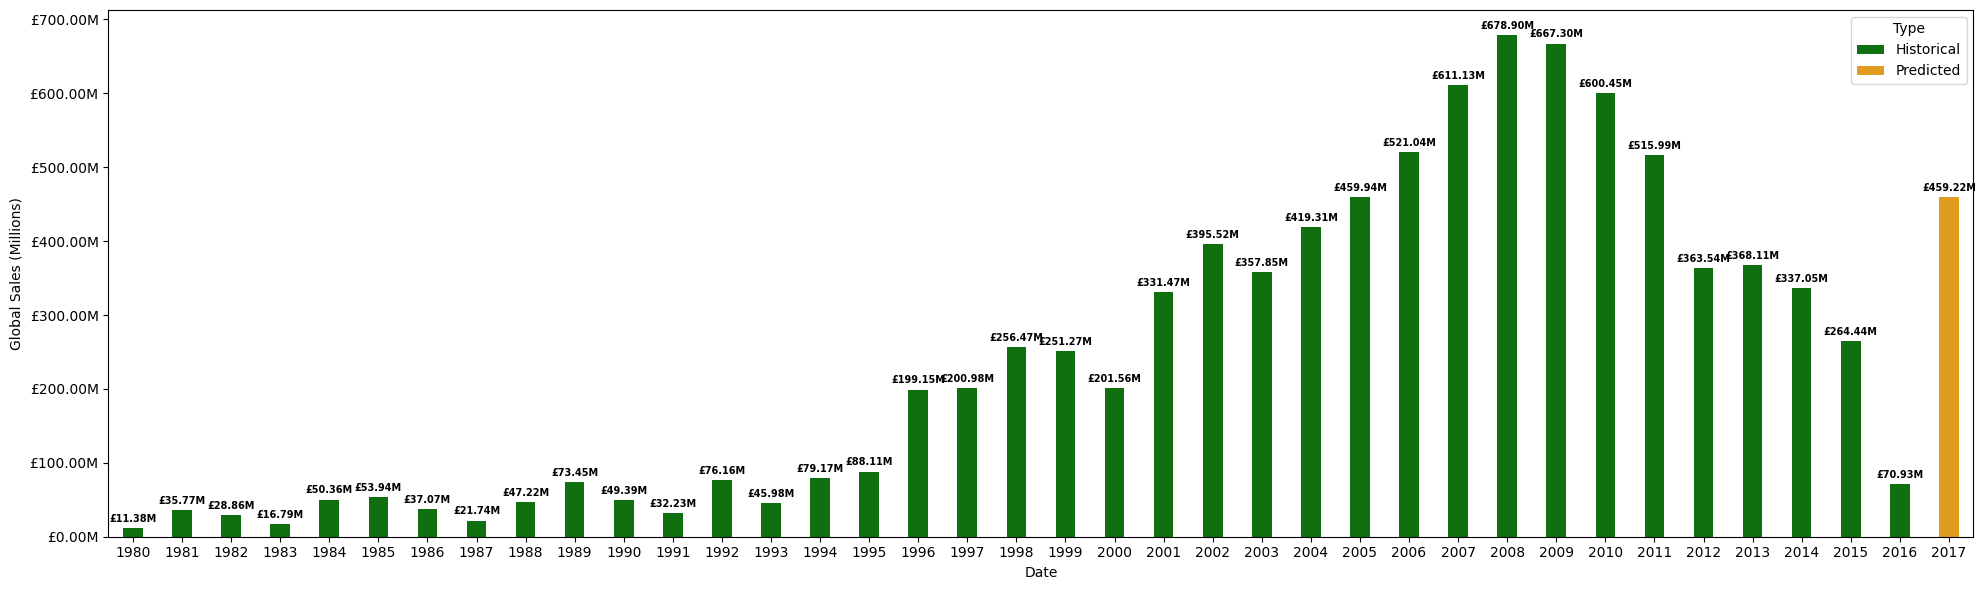

In [187]:
plt.figure(figsize=(20, 6))

ax = sns.barplot(
    x='year',
    y='y',
    data=plot_df,
    hue='Type',                  
    palette={'Historical':'green', 'Predicted':'orange'},
    dodge=False,
    width=0.4
)

ax.set_xlabel("Date", fontsize=10)
ax.set_ylabel("Global Sales (Millions)", fontsize=10)


for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
        f'£{height:.2f}M',
        (p.get_x() + p.get_width() / 2., height),
        ha='center',
        va='bottom',
        fontsize=7,
        fontweight='bold',
        xytext=(0, 3),
        textcoords='offset points'
    )


ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x:.2f}M'))

plt.tight_layout()
plt.show()